In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


plt.rcParams.update({
    "figure.facecolor": "#F8F5EF",
    "axes.facecolor": "#F8F5EF",
    "axes.edgecolor": "#2B2B2B",
    "text.color": "#2B2B2B",
    "axes.labelcolor": "#2B2B2B",
    "xtick.color": "#2B2B2B",
    "ytick.color": "#2B2B2B",
    "grid.color": "#DCD5C9",
})


cols = ["cord_uid", "title", "abstract", "publish_time",
        "authors", "journal", "license", "doi", "source_x"]

dtypes = {
    "cord_uid": "string",
    "title": "string",
    "abstract": "string",
    "authors": "string",
    "journal": "string",
    "license": "category",
    "doi": "string",
    "source_x": "category",
}

df = pd.read_csv("../data/metadata.csv", usecols=cols, dtype=dtypes, low_memory=False)
df["publish_time"] = pd.to_datetime(df["publish_time"], errors="coerce")
df = df.dropna(subset=["abstract"])

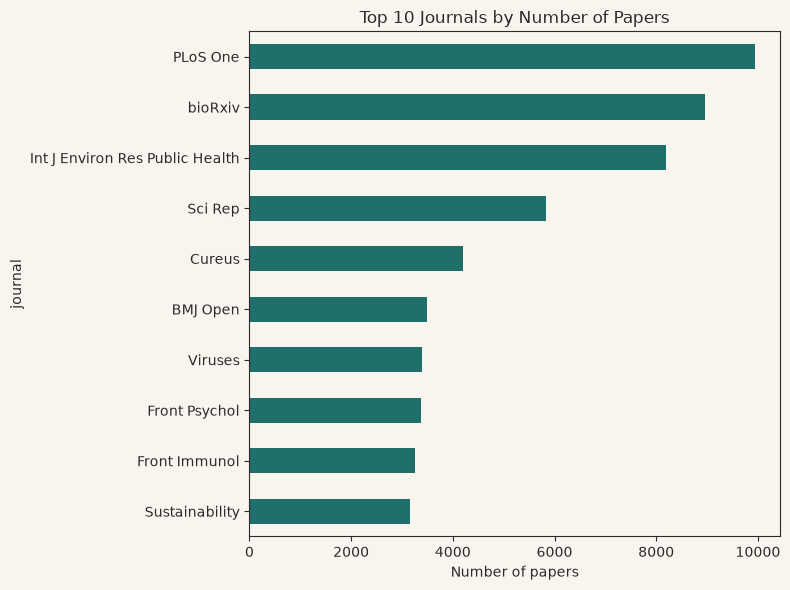

In [ ]:
top_journals = df["journal"].value_counts().head(10).sort_values(ascending=True)


fig, ax = plt.subplots(figsize=(8, 6))
top_journals.plot(kind="barh", color="#1F6F6B", ax=ax)
ax.set_title("Top 10 Journals by Number of Papers")
ax.set_xlabel("Number of papers")
plt.tight_layout()
plt.savefig("../figures/top_journals.png", dpi=150)

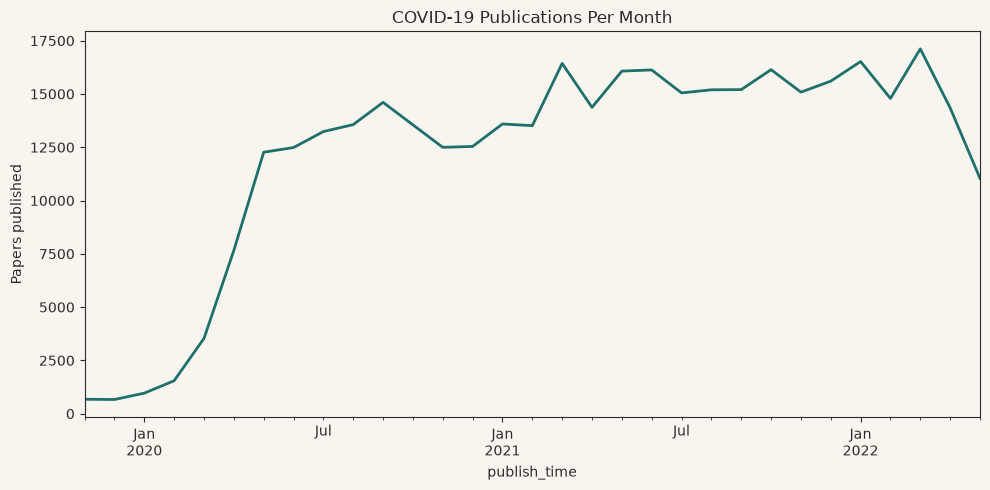

In [9]:
monthly = df.set_index("publish_time").resample("ME").size()
monthly = monthly[(monthly.index >= "2019-11-01") & (monthly.index <= "2022-06-01")]

fig, ax = plt.subplots(figsize=(10, 5))
monthly.plot(ax=ax, color="#1F6F6B", linewidth=2)
ax.set_title("COVID-19 Publications Per Month")
ax.set_ylabel("Papers published")
plt.tight_layout()
plt.savefig("../figures/monthly_volume.png", dpi=150)

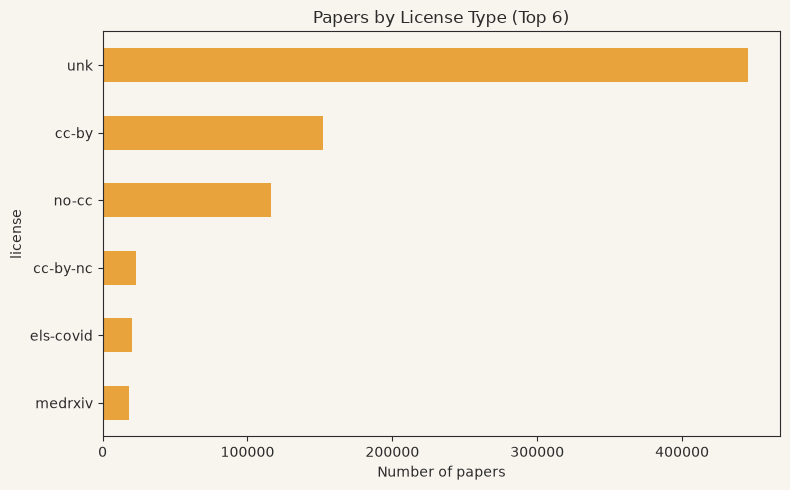

In [10]:
license_counts = df["license"].value_counts().head(6).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
license_counts.plot(kind="barh", color="#E8A33D", ax=ax)
ax.set_title("Papers by License Type (Top 6)")
ax.set_xlabel("Number of papers")
plt.tight_layout()
plt.savefig("../figures/licenses.png", dpi=150)